# Week 11 Deliverable: 4 Panel-EDA Report

#### We are working on 2x2 figure and EDA, main Goal such are:
- showing one distribution plot
- showing correlation heatmap by numeric columns
- using boxplot by category `Total Spent` on `Item`
- using scatter plot with a trendline

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('clean_data.csv')
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Day of the Week,Transaction Month,month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,September,9
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,Tuesday,May,5
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,Wednesday,July,7
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,Thursday,April,4
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday,June,6


In [3]:
df.dtypes

Transaction ID           str
Item                     str
Quantity             float64
Price Per Unit       float64
Total Spent          float64
Payment Method           str
Location                 str
Transaction Date         str
Day of the Week          str
Transaction Month        str
month                  int64
dtype: object

In [4]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

num_cols = ['Quantity', 'Price Per Unit', 'Total Spent', 'month']

boxplot_df = df[df['Item'] != 'Unknown'].copy()

plot_order = (
    boxplot_df.groupby('Item')['Total Spent']
    .median()
    .sort_values(ascending=False)
    .index
)



In [5]:
sns.set_theme(style='whitegrid', palette='Set2')


## Layout plan

- Panel 1: Histogram with KDE for `Total Spent`
- Panel 2: correlation heatmap with `Quantity	Price Per Unit	Total Spent` & `month`
- Panel 3: boxplot of `Total Spent` grouped by `Item`
- Panel 4: scatter plot of `Quantity` vs `Total Spent` with `sns.regplot`

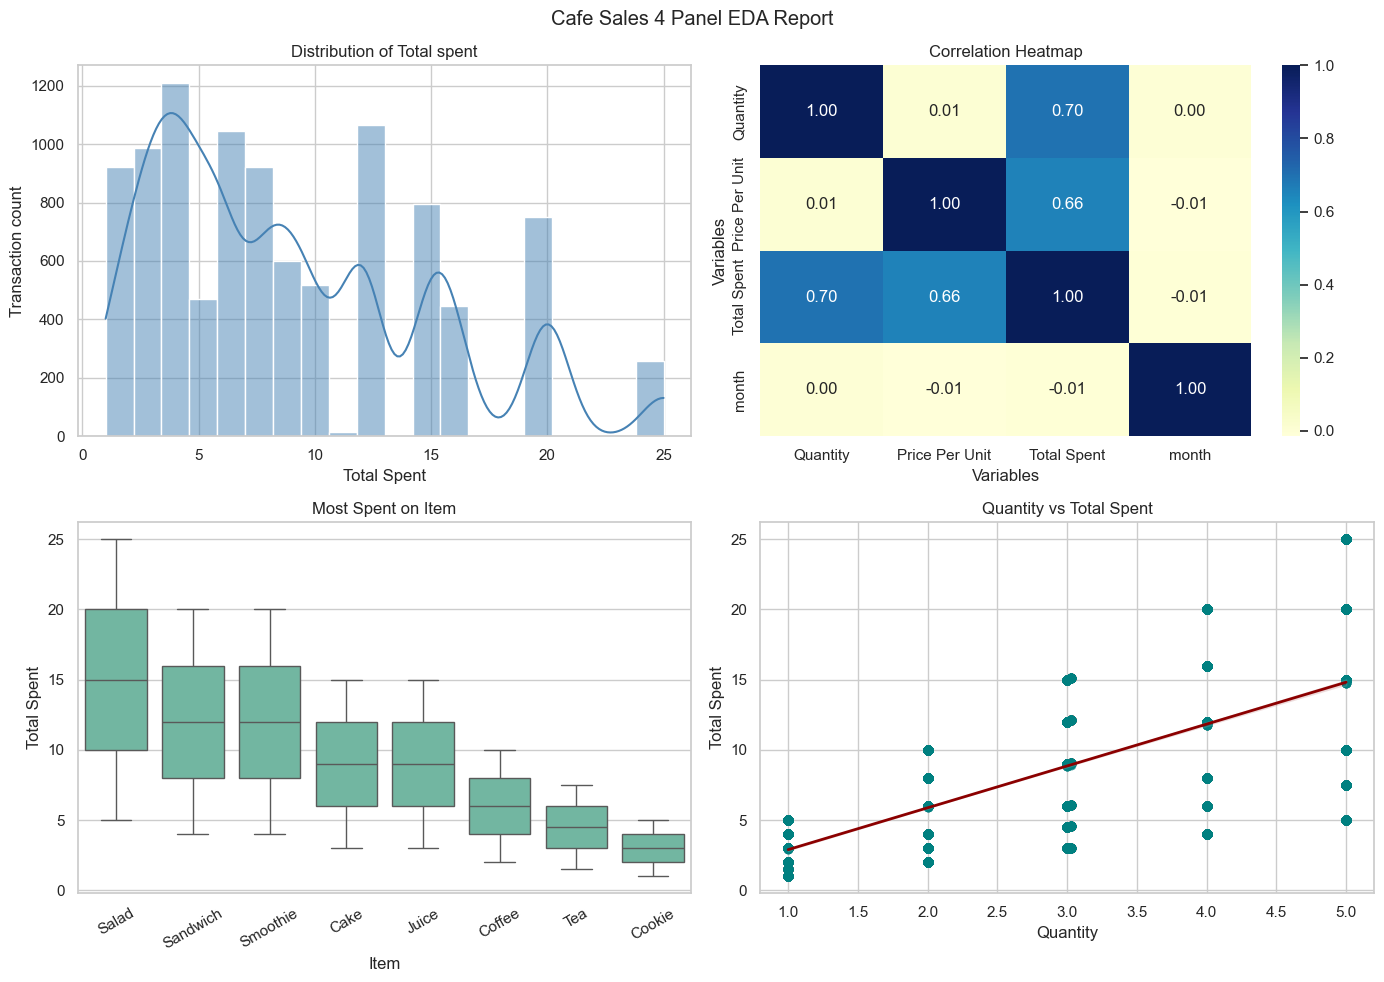

In [7]:
fig , axes = plt.subplots(2,2, figsize=(14,10))

# comparing histogram for Total spent
sns.histplot(df['Total Spent'],bins=20, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_ylabel('Transaction count')
axes[0,0].set_title('Distribution of Total spent')

# correlation heatmap of numeric cols
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[0,1], annot=True, fmt='.2f', cmap='YlGnBu')
axes[0,1].set_ylabel('Variables')
axes[0,1].set_xlabel('Variables')
axes[0,1].set_title('Correlation Heatmap')

# Boxplot by Category`Item`
sns.boxplot(y='Total Spent', x='Item', data=boxplot_df, ax=axes[1,0], order=plot_order, showfliers=False)
axes[1,0].set_title('Most Spent on Item')
axes[1,0].tick_params(axis='x', rotation=30)

# regplot with trendline
sns.regplot(x='Quantity', y='Total Spent', data=df, ax=axes[1,1],  scatter_kws={'alpha':0.35, 'color': 'teal'},
            line_kws={'linewidth':2, 'color': 'darkred'})
axes[1, 1].set_title('Quantity vs Total Spent')


fig.suptitle('Cafe Sales 4 Panel EDA Report')
plt.tight_layout()
fig.savefig('cafe_sales_eda_report.png', dpi=150, bbox_inches='tight')
plt.show()

### Quick read from the report:

- `Total Spent` stays more concentrated in the lower range, with a right tail.
- `Quantity` and `Total Spent` have a clear positive trend.
- item categories show different spread in total spend.
- the heatmap confirms that `Total Spent` is strongly related to `Quantity` and `Price Per Unit`.